# Target relationships — approval rate by feature

How does the approval decision (`target`) vary across the protected attributes and core loan/financial
fields kept by `data_cleaning.ipynb`? This is the systematic feature-vs-target pass that notebook didn't
cover — its EDA was either univariate (distributions, missingness) or narrowly target-conditional just
for leakage detection, and the automated `ydata-profiling` report runs in `minimal=True` mode, which
explicitly disables correlations and pairwise/target interactions.

**Uses `data/processed/train.parquet` only** — not `val`/`test`. Any exploratory conclusion drawn here
should hold up independent of the data reserved for evaluation; looking at val/test now would mean
decisions made from this notebook have already "seen" the data the team evaluates models on later.

**Scope:** every kept feature (`data_cleaning.ipynb` now keeps 48) **except** four pure identifiers —
`lei`, `derived_msa_md`, `county_code`, `census_tract` — which have thousands of distinct values and
don't produce a readable bar chart without a geographic aggregation step this notebook doesn't do.
Everything else gets a chart: protected attributes and core loan/financial fields first, then the
remaining loan/product characteristics and tract-level geographic context. Extending to the 4 excluded
columns (or any new feature) means adding another call to the same two helper functions below.

**Color convention, used consistently throughout:** blue = denied (`target=0`), orange = originated
(`target=1`) — the same validated pair the rest of the project's palette uses for a 2-series
comparison.

In [1]:
from pathlib import Path
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

TRAIN_PATH = Path("../data/processed/train.parquet")
train = pl.read_parquet(TRAIN_PATH)
print(f"{train.height:,} rows, {train.width} columns")

COLOR_DENIED = "#2a78d6"      # target = 0
COLOR_ORIGINATED = "#eb6834"  # target = 1
OVERALL_RATE = train["target"].mean()

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
    "font.size": 10,
    "figure.dpi": 100,
})

6,393,228 rows, 49 columns


## Helper functions

One for categorical features (bar chart of approval rate per category, sample size annotated), one for
numeric features (density overlay split by outcome, means/medians printed below).

In [2]:
def approval_rate_by_category(df, col, order=None, labels=None, title=None):
    """Bar chart of approval rate per category, sorted by rate unless an explicit order is given."""
    g = df.group_by(col).agg(pl.len().alias("n"), pl.col("target").mean().alias("approval_rate"))
    pdf = g.to_pandas()
    raw = pdf[col].fillna("(missing)")  # nulls get their own bar, labeled clearly rather than as "None"
    pdf[col] = raw.map(labels).fillna(raw.astype(str)) if labels else raw
    if order:
        cats = [labels.get(o, o) if labels else o for o in order]
        pdf[col] = pd.Categorical(pdf[col], categories=cats, ordered=True)
        pdf = pdf.sort_values(col)
    else:
        pdf = pdf.sort_values("approval_rate")

    fig, ax = plt.subplots(figsize=(7, max(2.2, 0.45 * len(pdf))))
    bars = ax.barh(pdf[col].astype(str), pdf["approval_rate"], color=COLOR_ORIGINATED, height=0.6)
    ax.axvline(OVERALL_RATE, color="0.4", linestyle="--", linewidth=1,
               label=f"overall rate ({OVERALL_RATE:.1%})")
    for bar, n in zip(bars, pdf["n"]):
        ax.text(bar.get_width() + 0.012, bar.get_y() + bar.get_height() / 2, f"n={n:,}",
                va="center", fontsize=8, color="0.35")
    ax.set_xlabel("Approval rate (target = 1)")
    ax.set_xlim(0, 1.12)
    ax.set_title(title or f"Approval rate by {col}")
    ax.legend(loc="lower right", frameon=False)
    plt.tight_layout()
    plt.show()
    return pdf[[col, "n", "approval_rate"]].reset_index(drop=True)


def distribution_by_target(df, col, bins=40, clip=None, log=False):
    """Overlaid density histogram split by target, means/medians printed below."""
    sub = df.select([col, "target"]).drop_nulls()
    pdf = sub.to_pandas()
    rng = clip if clip else (pdf[col].min(), pdf[col].max())

    fig, ax = plt.subplots(figsize=(7, 4))
    for t, color, label in [(0, COLOR_DENIED, "Denied"), (1, COLOR_ORIGINATED, "Originated")]:
        vals = pdf.loc[pdf["target"] == t, col]
        ax.hist(vals, bins=bins, range=rng, density=True, alpha=0.55, color=color,
                label=f"{label} (n={len(vals):,})")
    ax.set_xlabel(col + (" (clipped to 1st-99th pctile for display)" if clip else ""))
    ax.set_ylabel("Density")
    ax.set_title(f"{col} distribution by outcome")
    if log:
        ax.set_xscale("log")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    stats = sub.group_by("target").agg(
        pl.col(col).mean().round(1).alias("mean"),
        pl.col(col).median().round(1).alias("median"),
    ).sort("target")
    print(stats)

## Protected attributes

### `derived_race`

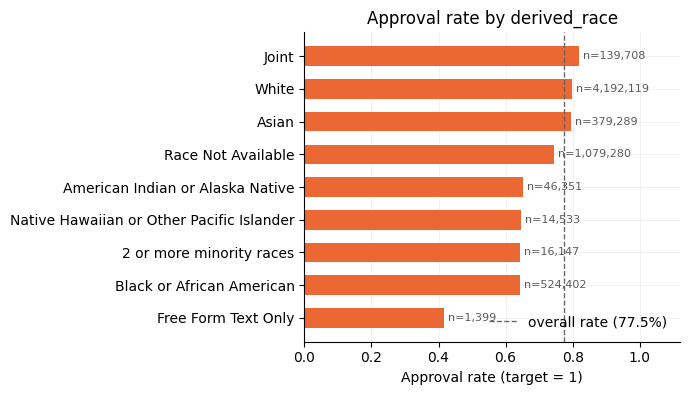

In [3]:
_ = approval_rate_by_category(train, "derived_race")

### `derived_ethnicity`

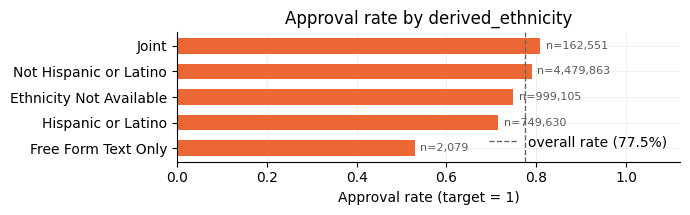

In [4]:
_ = approval_rate_by_category(train, "derived_ethnicity")

### `derived_sex`

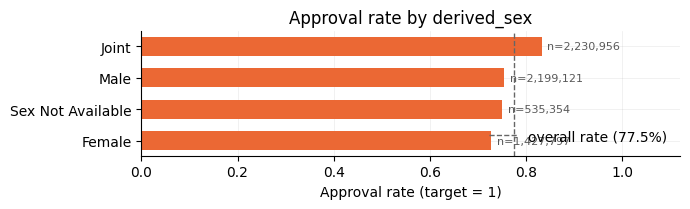

In [5]:
_ = approval_rate_by_category(train, "derived_sex")

### `applicant_age`

Ordered by age band rather than by rate, since the bands have a natural order.

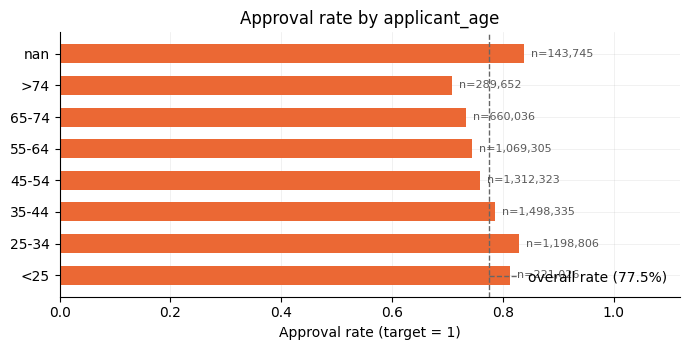

In [6]:
AGE_ORDER = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]
_ = approval_rate_by_category(train, "applicant_age", order=AGE_ORDER)

### `has_co_applicant`

Derived in `data_cleaning.ipynb` §4e from `co_applicant_age`'s sentinel value.

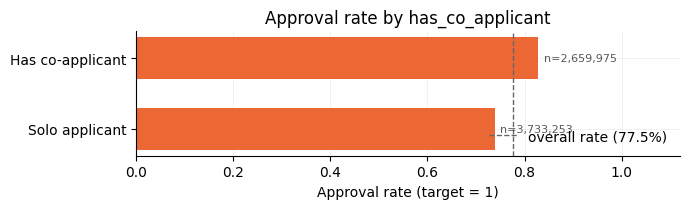

In [7]:
_ = approval_rate_by_category(
    train, "has_co_applicant",
    labels={True: "Has co-applicant", False: "Solo applicant"},
)

## Core loan / financial fields

### `loan_type`

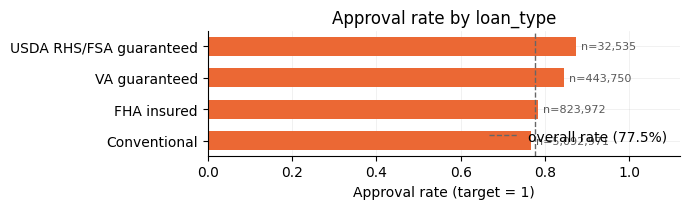

In [8]:
LOAN_TYPE_LABELS = {1: "Conventional", 2: "FHA insured", 3: "VA guaranteed", 4: "USDA RHS/FSA guaranteed"}
_ = approval_rate_by_category(train, "loan_type", labels=LOAN_TYPE_LABELS)

### `loan_purpose`

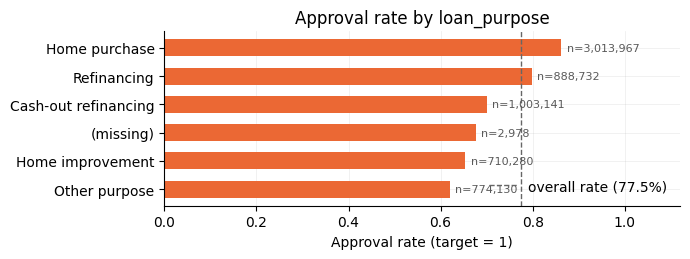

In [9]:
LOAN_PURPOSE_LABELS = {
    1: "Home purchase", 2: "Home improvement", 31: "Refinancing",
    32: "Cash-out refinancing", 4: "Other purpose", 5: "Not applicable",
}
_ = approval_rate_by_category(train, "loan_purpose", labels=LOAN_PURPOSE_LABELS)

### `occupancy_type`

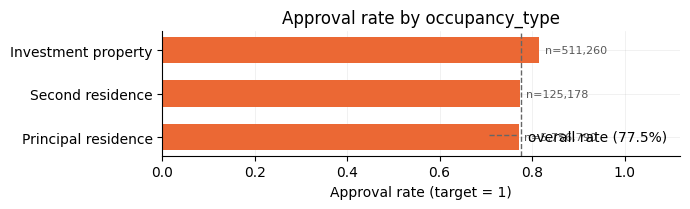

In [10]:
OCCUPANCY_TYPE_LABELS = {1: "Principal residence", 2: "Second residence", 3: "Investment property"}
_ = approval_rate_by_category(train, "occupancy_type", labels=OCCUPANCY_TYPE_LABELS)

### `loan_amount`

Heavy right tail (privacy-preserving reporting allows very large values) — display clipped to the
1st-99th percentile ($15,000-$1,565,000); the underlying data isn't altered, only the chart range.

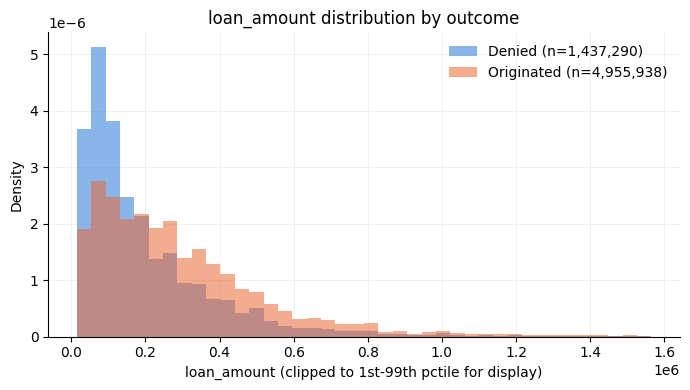

shape: (2, 3)
┌────────┬──────────┬──────────┐
│ target ┆ mean     ┆ median   │
│ ---    ┆ ---      ┆ ---      │
│ i8     ┆ f64      ┆ f64      │
╞════════╪══════════╪══════════╡
│ 0      ┆ 220295.0 ┆ 135000.0 │
│ 1      ┆ 343887.2 ┆ 245000.0 │
└────────┴──────────┴──────────┘


In [11]:
distribution_by_target(train, "loan_amount", clip=(15_000, 1_565_000))

### `income`

Reported in thousands of dollars. Same heavy-tail clipping as `loan_amount`.

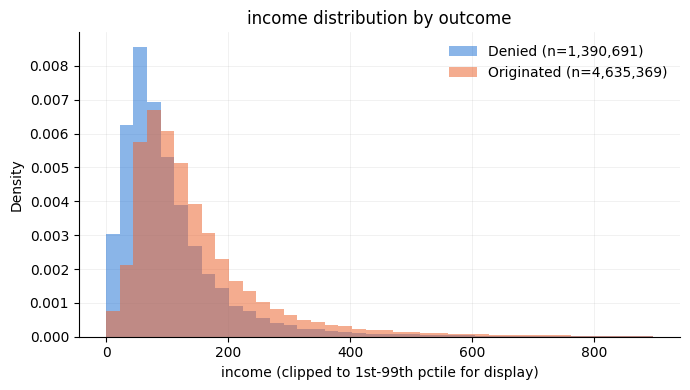

shape: (2, 3)
┌────────┬───────┬────────┐
│ target ┆ mean  ┆ median │
│ ---    ┆ ---   ┆ ---    │
│ i8     ┆ f64   ┆ f64    │
╞════════╪═══════╪════════╡
│ 0      ┆ 216.0 ┆ 81.0   │
│ 1      ┆ 191.2 ┆ 116.0  │
└────────┴───────┴────────┘


In [12]:
distribution_by_target(train, "income", clip=(0, 896))

### `combined_loan_to_value_ratio`

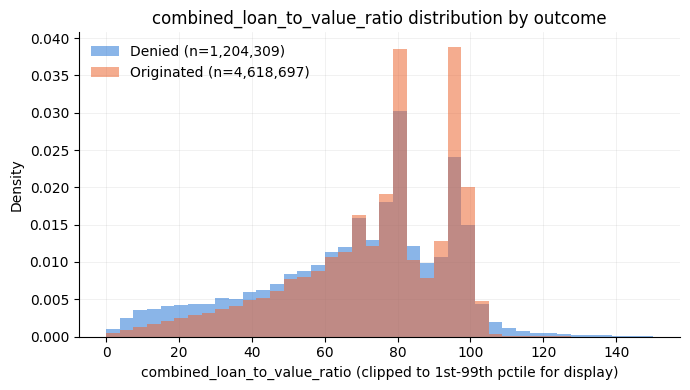

shape: (2, 3)
┌────────┬────────┬────────┐
│ target ┆ mean   ┆ median │
│ ---    ┆ ---    ┆ ---    │
│ i8     ┆ f64    ┆ f64    │
╞════════╪════════╪════════╡
│ 0      ┆ 1780.1 ┆ 74.5   │
│ 1      ┆ 139.5  ┆ 78.8   │
└────────┴────────┴────────┘


In [13]:
distribution_by_target(train, "combined_loan_to_value_ratio", clip=(0, 150))

### `debt_to_income_ratio`

Recall from `data_cleaning.ipynb` §4e: values above 60% and below 20% are bucket-midpoint estimates
(70 and 10 respectively), not exact reported numbers — the spike at 70 reflects that, not a real
concentration of applicants exactly at 70%.

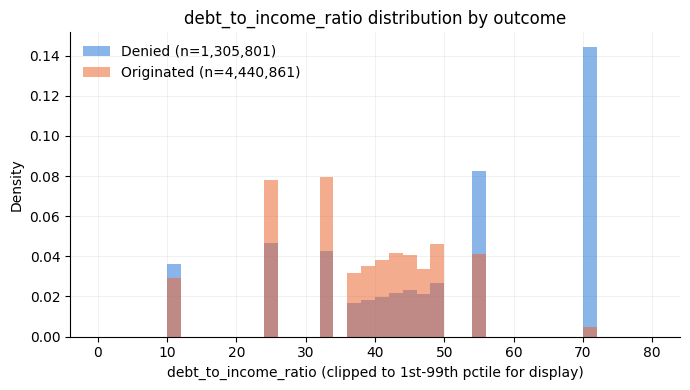

shape: (2, 3)
┌────────┬──────┬────────┐
│ target ┆ mean ┆ median │
│ ---    ┆ ---  ┆ ---    │
│ i8     ┆ f64  ┆ f64    │
╞════════╪══════╪════════╡
│ 0      ┆ 47.9 ┆ 48.0   │
│ 1      ┆ 37.8 ┆ 39.0   │
└────────┴──────┴────────┘


In [14]:
distribution_by_target(train, "debt_to_income_ratio", clip=(0, 80))

### `property_value`

Same heavy-tail clipping rationale as `loan_amount`.

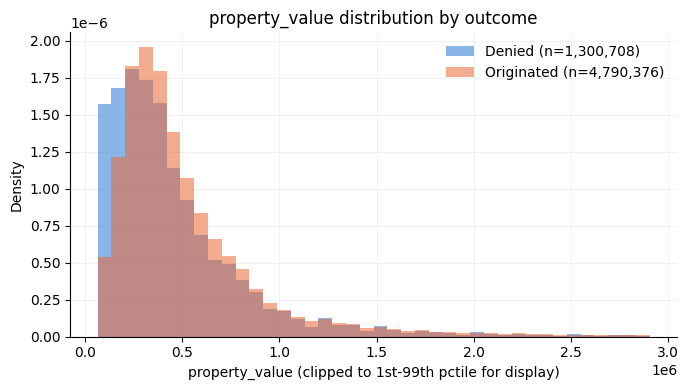

shape: (2, 3)
┌────────┬──────────┬──────────┐
│ target ┆ mean     ┆ median   │
│ ---    ┆ ---      ┆ ---      │
│ i8     ┆ f64      ┆ f64      │
╞════════╪══════════╪══════════╡
│ 0      ┆ 525835.4 ┆ 355000.0 │
│ 1      ┆ 606206.9 ┆ 405000.0 │
└────────┴──────────┴──────────┘


In [15]:
distribution_by_target(train, "property_value", clip=(65_000, 2_905_000))

## Remaining loan / product characteristics

Everything else `data_cleaning.ipynb` kept, except the 4 high-cardinality identifiers noted above.
Straightforward string categoricals first, then coded fields mapped to readable labels (per the
[official field docs](https://ffiec.cfpb.gov/documentation/publications/loan-level-datasets/lar-data-fields)),
then `state_code` (55 values — a long chart, sorted by rate like the others).

### `conforming_loan_limit`, `derived_loan_product_type`, `derived_dwelling_category`

Already human-readable strings, no label mapping needed.

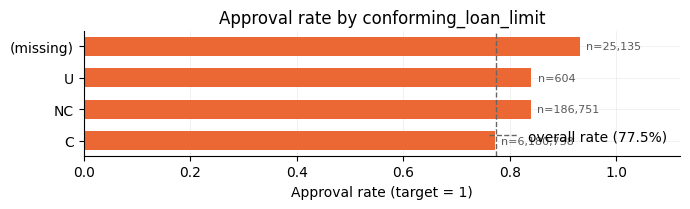

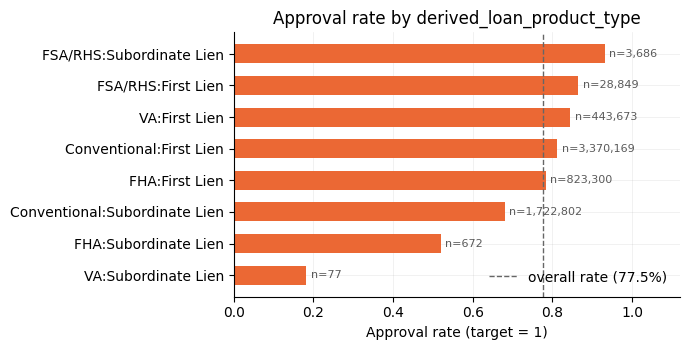

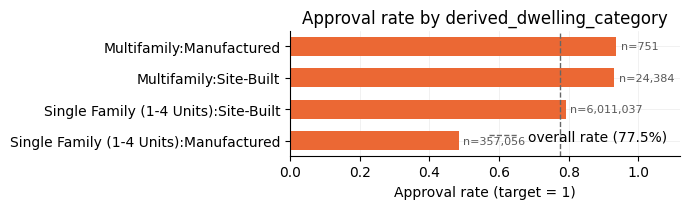

In [16]:
for col in ["conforming_loan_limit", "derived_loan_product_type", "derived_dwelling_category"]:
    approval_rate_by_category(train, col)

### `lien_status`, `construction_method`

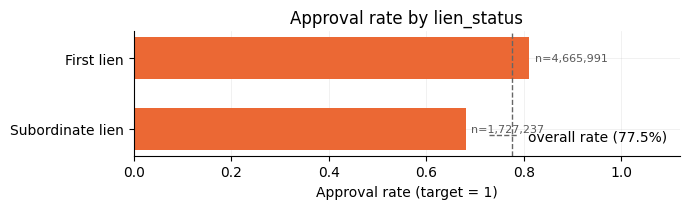

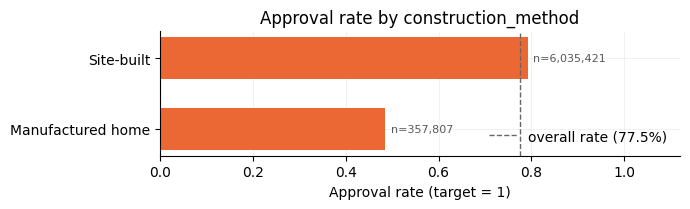

In [17]:
_ = approval_rate_by_category(train, "lien_status", labels={1: "First lien", 2: "Subordinate lien"})
_ = approval_rate_by_category(train, "construction_method", labels={1: "Site-built", 2: "Manufactured home"})

### 7 binary loan-structure flags

`reverse_mortgage`, `open_end_line_of_credit`, `business_or_commercial_purpose`,
`negative_amortization`, `interest_only_payment`, `balloon_payment`, `other_nonamortizing_features`
— each is a 1/2 flag (their `1111` "Exempt" sentinel already nulled in `data_cleaning.ipynb`), grouped
here since they share the same shape rather than repeating near-identical cells.

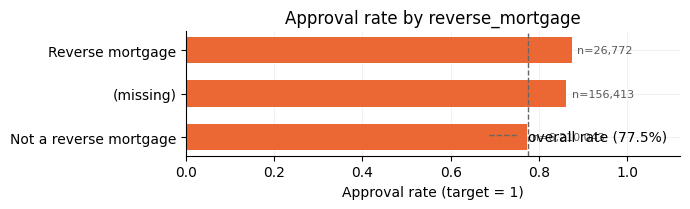

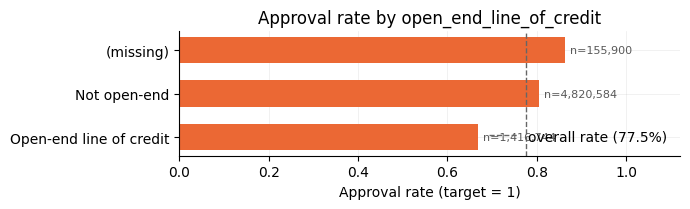

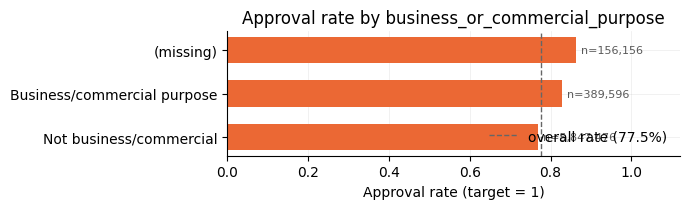

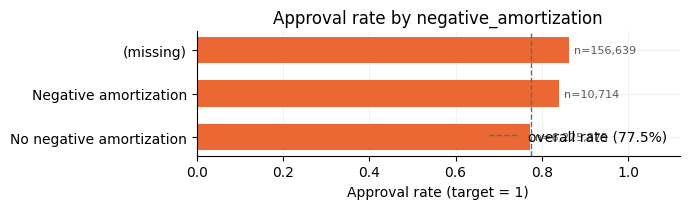

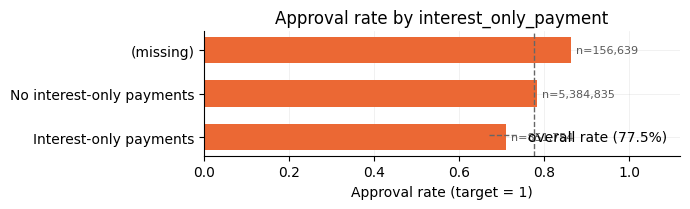

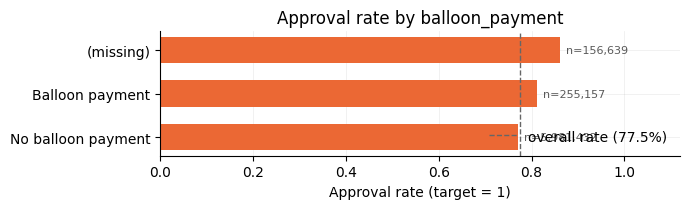

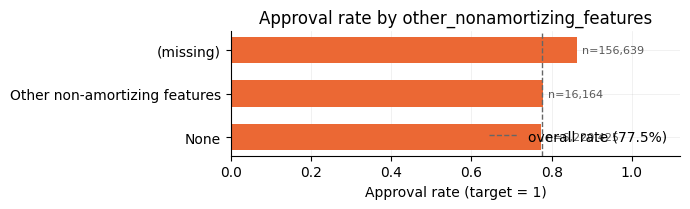

In [18]:
BINARY_FLAG_LABELS = {
    "reverse_mortgage": {1: "Reverse mortgage", 2: "Not a reverse mortgage"},
    "open_end_line_of_credit": {1: "Open-end line of credit", 2: "Not open-end"},
    "business_or_commercial_purpose": {1: "Business/commercial purpose", 2: "Not business/commercial"},
    "negative_amortization": {1: "Negative amortization", 2: "No negative amortization"},
    "interest_only_payment": {1: "Interest-only payments", 2: "No interest-only payments"},
    "balloon_payment": {1: "Balloon payment", 2: "No balloon payment"},
    "other_nonamortizing_features": {1: "Other non-amortizing features", 2: "None"},
}
for col, labels in BINARY_FLAG_LABELS.items():
    approval_rate_by_category(train, col, labels=labels)

### `manufactured_home_secured_property_type`, `manufactured_home_land_property_interest`

Code 3 / code 5 ("Not applicable") are 92%+ of rows here — genuine skip logic for non-manufactured-home
loans (kept, not nulled, in `data_cleaning.ipynb` §4f), so they show up as the dominant category below.

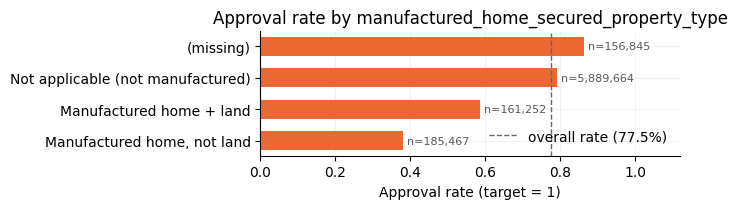

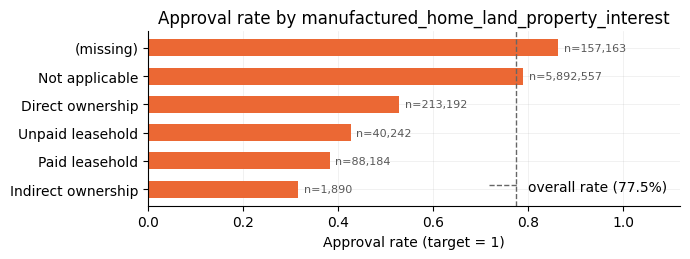

In [19]:
_ = approval_rate_by_category(
    train, "manufactured_home_secured_property_type",
    labels={1: "Manufactured home + land", 2: "Manufactured home, not land", 3: "Not applicable (not manufactured)"},
)
_ = approval_rate_by_category(
    train, "manufactured_home_land_property_interest",
    labels={1: "Direct ownership", 2: "Indirect ownership", 3: "Paid leasehold",
            4: "Unpaid leasehold", 5: "Not applicable"},
)

### `submission_of_application`, `initially_payable_to_institution`

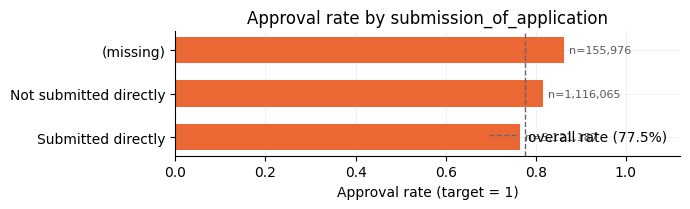

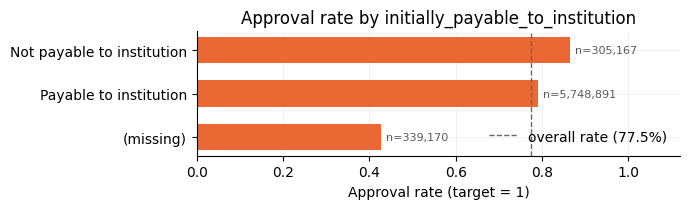

In [20]:
_ = approval_rate_by_category(train, "submission_of_application",
    labels={1: "Submitted directly", 2: "Not submitted directly"})
_ = approval_rate_by_category(train, "initially_payable_to_institution",
    labels={1: "Payable to institution", 2: "Not payable to institution"})

### `aus_1` — automated underwriting system used

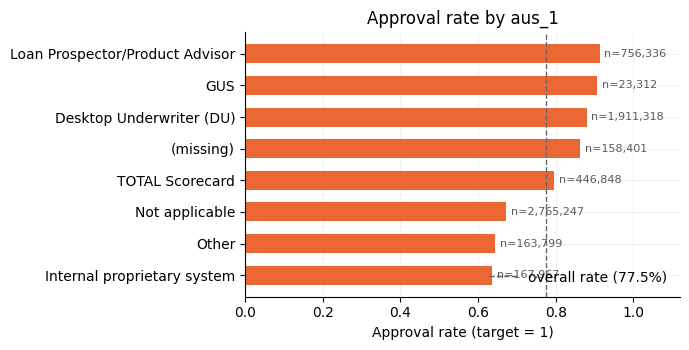

In [21]:
AUS_LABELS = {
    1: "Desktop Underwriter (DU)", 2: "Loan Prospector/Product Advisor", 3: "TOTAL Scorecard",
    4: "GUS", 5: "Other", 6: "Not applicable", 7: "Internal proprietary system",
}
_ = approval_rate_by_category(train, "aus_1", labels=AUS_LABELS)

### `applicant_credit_score_type`, `co_applicant_credit_score_type`

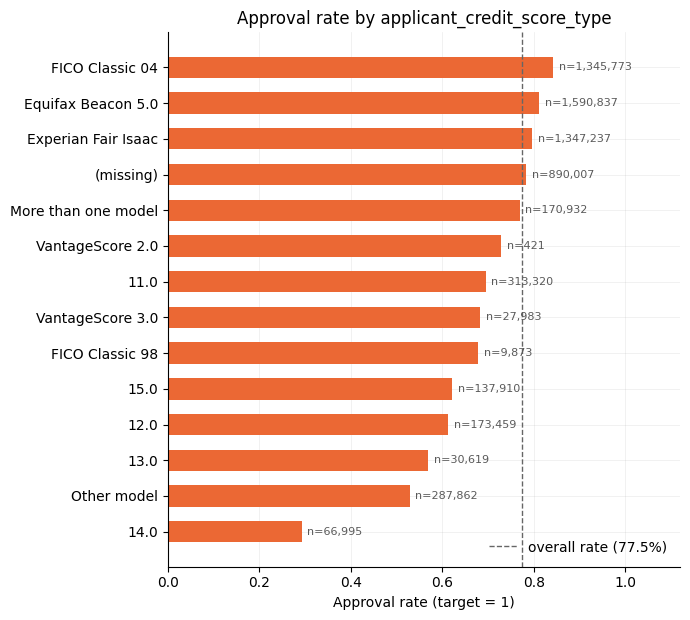

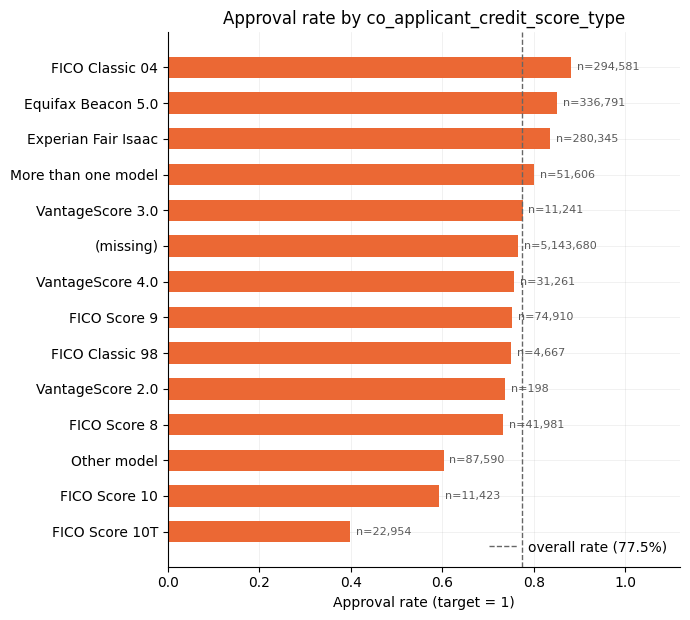

In [22]:
CREDIT_SCORE_TYPE_LABELS = {
    1: "Equifax Beacon 5.0", 2: "Experian Fair Isaac", 3: "FICO Classic 04", 4: "FICO Classic 98",
    5: "VantageScore 2.0", 6: "VantageScore 3.0", 7: "More than one model", 8: "Other model",
}
CO_CREDIT_SCORE_TYPE_LABELS = {
    **CREDIT_SCORE_TYPE_LABELS,
    11: "FICO Score 9", 12: "FICO Score 8", 13: "FICO Score 10", 14: "FICO Score 10T",
    15: "VantageScore 4.0",
}
_ = approval_rate_by_category(train, "applicant_credit_score_type", labels=CREDIT_SCORE_TYPE_LABELS)
_ = approval_rate_by_category(train, "co_applicant_credit_score_type", labels=CO_CREDIT_SCORE_TYPE_LABELS)

### `co_applicant_age`

Same age-band treatment and ordering as `applicant_age`. Nulls here mean either no co-applicant
(captured separately by `has_co_applicant`) or a co-applicant with age not available.

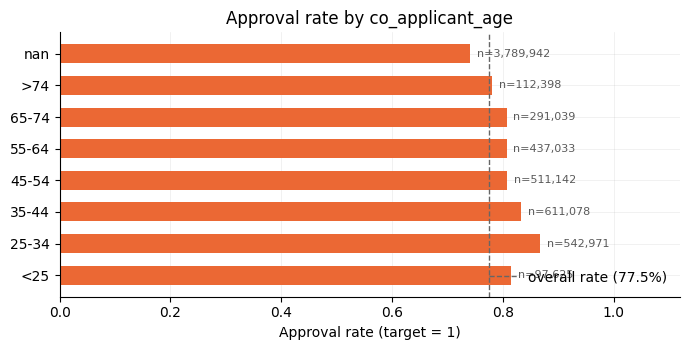

In [23]:
_ = approval_rate_by_category(train, "co_applicant_age", order=AGE_ORDER)

### `state_code`

55 values — sorted by rate rather than a fixed order, so the chart is tall.

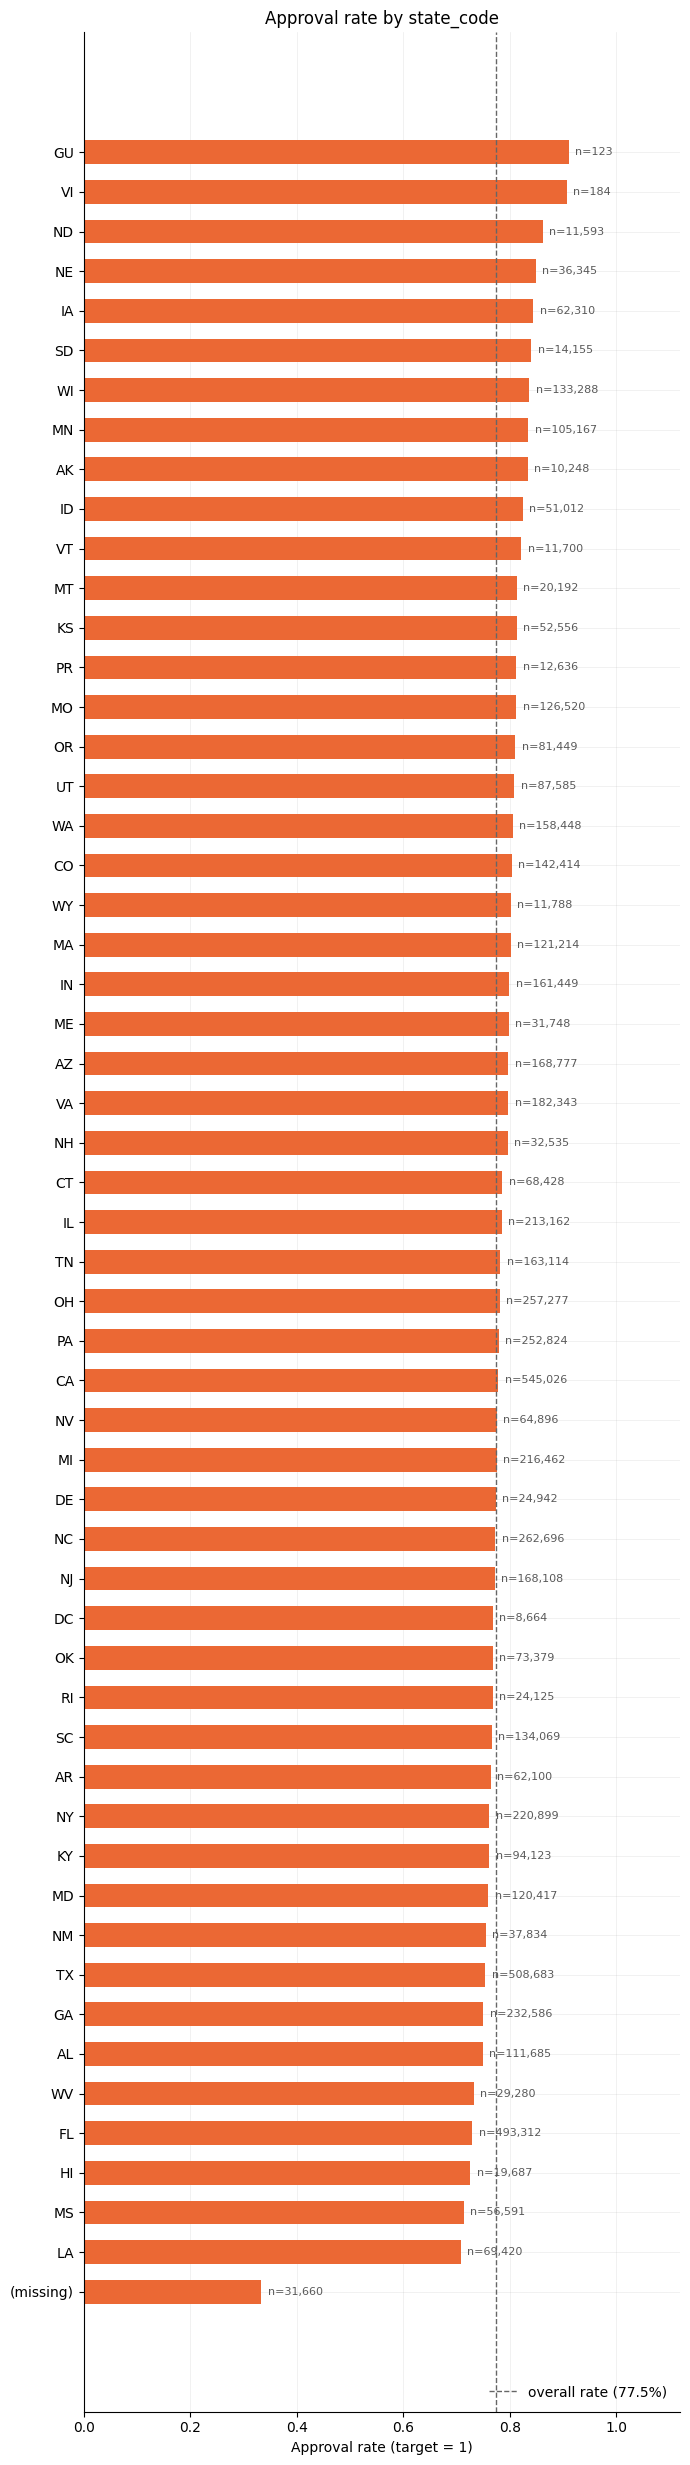

In [24]:
_ = approval_rate_by_category(train, "state_code")

## Remaining geographic & tract-level context

Census-tract-level fields describing the neighborhood the property is in, not the applicant. Ranges
clipped to 1st-99th percentile for display — none of these have a heavy tail like `loan_amount`, but
clipping keeps the chart consistent with the rest of this notebook.

`tract_minority_population_percent` in particular is a classic fairness-relevant field (neighborhood
racial composition vs. approval rate is the crux of redlining-style analysis) — worth close attention
in the team's model interpretation, not just here.

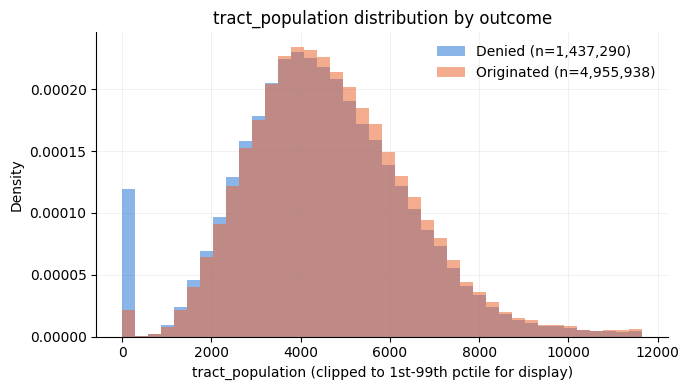

shape: (2, 3)
┌────────┬────────┬────────┐
│ target ┆ mean   ┆ median │
│ ---    ┆ ---    ┆ ---    │
│ i8     ┆ f64    ┆ f64    │
╞════════╪════════╪════════╡
│ 0      ┆ 4571.1 ┆ 4388.0 │
│ 1      ┆ 4802.3 ┆ 4548.0 │
└────────┴────────┴────────┘


In [25]:
distribution_by_target(train, "tract_population", clip=(0, 11_656))

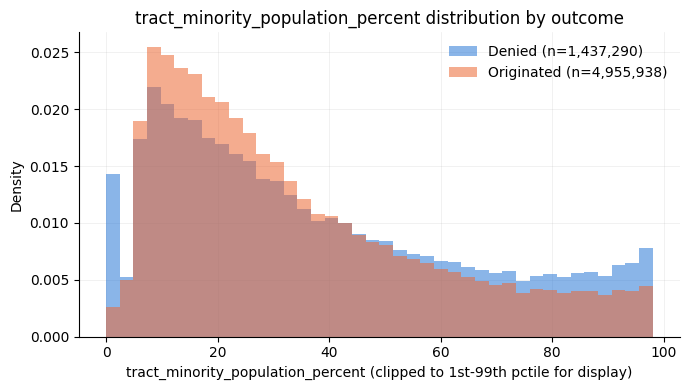

shape: (2, 3)
┌────────┬──────┬────────┐
│ target ┆ mean ┆ median │
│ ---    ┆ ---  ┆ ---    │
│ i8     ┆ f64  ┆ f64    │
╞════════╪══════╪════════╡
│ 0      ┆ 38.4 ┆ 31.1   │
│ 1      ┆ 34.8 ┆ 27.4   │
└────────┴──────┴────────┘


In [26]:
distribution_by_target(train, "tract_minority_population_percent", clip=(0, 98))

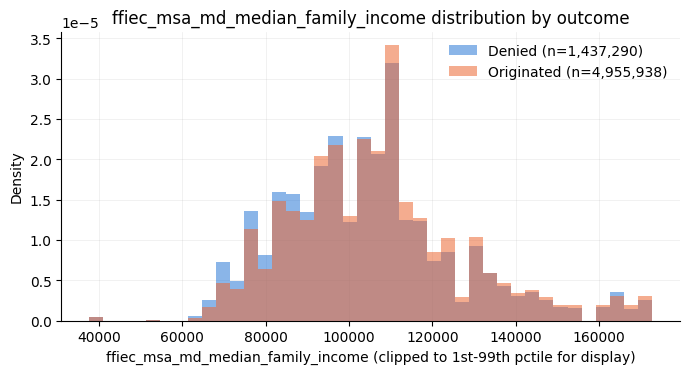

shape: (2, 3)
┌────────┬──────────┬──────────┐
│ target ┆ mean     ┆ median   │
│ ---    ┆ ---      ┆ ---      │
│ i8     ┆ f64      ┆ f64      │
╞════════╪══════════╪══════════╡
│ 0      ┆ 102968.4 ┆ 102300.0 │
│ 1      ┆ 106683.4 ┆ 105600.0 │
└────────┴──────────┴──────────┘


In [27]:
distribution_by_target(train, "ffiec_msa_md_median_family_income", clip=(37_700, 172_700))

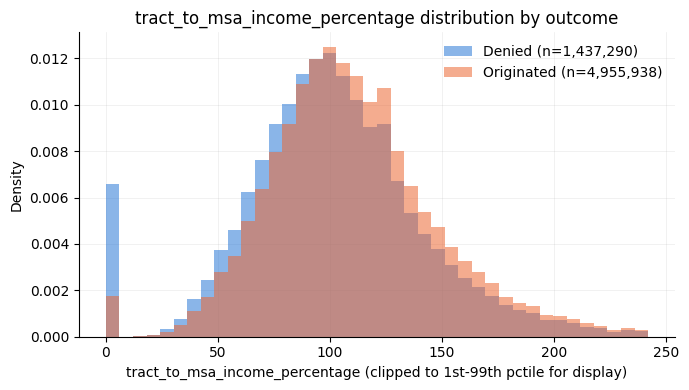

shape: (2, 3)
┌────────┬───────┬────────┐
│ target ┆ mean  ┆ median │
│ ---    ┆ ---   ┆ ---    │
│ i8     ┆ f64   ┆ f64    │
╞════════╪═══════╪════════╡
│ 0      ┆ 102.4 ┆ 100.0  │
│ 1      ┆ 111.3 ┆ 107.0  │
└────────┴───────┴────────┘


In [28]:
distribution_by_target(train, "tract_to_msa_income_percentage", clip=(0, 242))

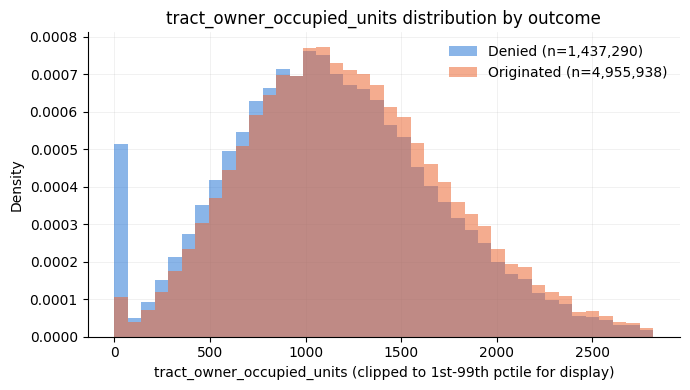

shape: (2, 3)
┌────────┬────────┬────────┐
│ target ┆ mean   ┆ median │
│ ---    ┆ ---    ┆ ---    │
│ i8     ┆ f64    ┆ f64    │
╞════════╪════════╪════════╡
│ 0      ┆ 1154.6 ┆ 1113.0 │
│ 1      ┆ 1241.4 ┆ 1189.0 │
└────────┴────────┴────────┘


In [29]:
distribution_by_target(train, "tract_owner_occupied_units", clip=(0, 2_819))

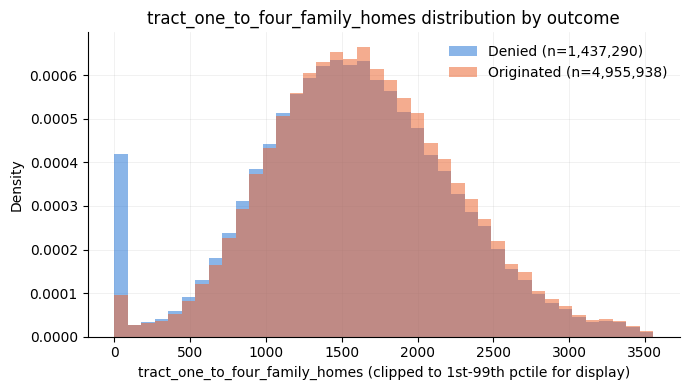

shape: (2, 3)
┌────────┬────────┬────────┐
│ target ┆ mean   ┆ median │
│ ---    ┆ ---    ┆ ---    │
│ i8     ┆ f64    ┆ f64    │
╞════════╪════════╪════════╡
│ 0      ┆ 1590.7 ┆ 1568.0 │
│ 1      ┆ 1666.0 ┆ 1620.0 │
└────────┴────────┴────────┘


In [30]:
distribution_by_target(train, "tract_one_to_four_family_homes", clip=(0, 3_554))

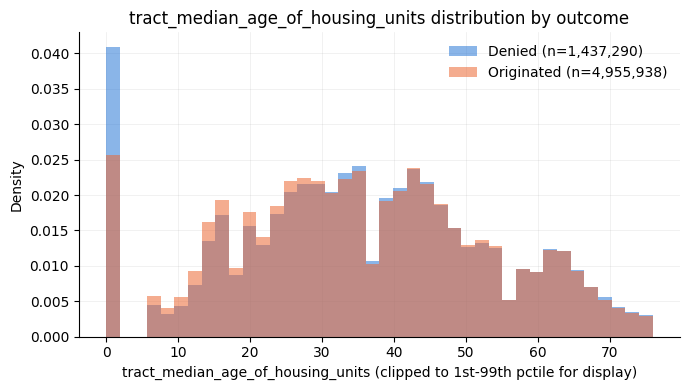

shape: (2, 3)
┌────────┬──────┬────────┐
│ target ┆ mean ┆ median │
│ ---    ┆ ---  ┆ ---    │
│ i8     ┆ f64  ┆ f64    │
╞════════╪══════╪════════╡
│ 0      ┆ 35.7 ┆ 36.0   │
│ 1      ┆ 36.0 ┆ 35.0   │
└────────┴──────┴────────┘


In [31]:
distribution_by_target(train, "tract_median_age_of_housing_units", clip=(0, 76))

### `loan_term`, `intro_rate_period`

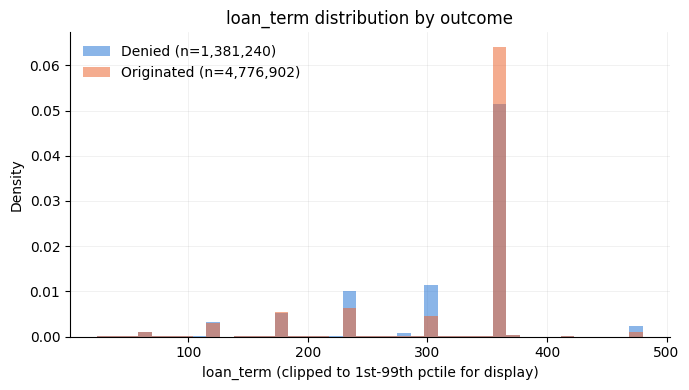

shape: (2, 3)
┌────────┬───────┬────────┐
│ target ┆ mean  ┆ median │
│ ---    ┆ ---   ┆ ---    │
│ i8     ┆ f64   ┆ f64    │
╞════════╪═══════╪════════╡
│ 0      ┆ 313.2 ┆ 360.0  │
│ 1      ┆ 319.8 ┆ 360.0  │
└────────┴───────┴────────┘


In [32]:
distribution_by_target(train, "loan_term", clip=(24, 480))

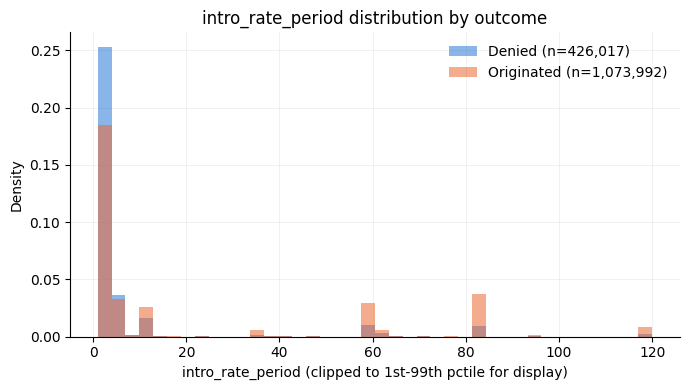

shape: (2, 3)
┌────────┬──────┬────────┐
│ target ┆ mean ┆ median │
│ ---    ┆ ---  ┆ ---    │
│ i8     ┆ f64  ┆ f64    │
╞════════╪══════╪════════╡
│ 0      ┆ 8.4  ┆ 1.0    │
│ 1      ┆ 23.6 ┆ 1.0    │
└────────┴──────┴────────┘


In [33]:
distribution_by_target(train, "intro_rate_period", clip=(1, 120))

## Extending this notebook

To add another feature: call `approval_rate_by_category(train, "column_name")` for a categorical field
(pass `labels={...}` to map codes to readable names, `order=[...]` if it has a natural order), or
`distribution_by_target(train, "column_name")` for a numeric one (pass `clip=(low, high)` if it has a
heavy tail). Both helpers are defined once, near the top of this notebook.